# Chapter 10 / Exercise 15

Build and train a classification MLP on the CoverType dataset:

  a. Load the dataset using `sklearn.datasets.fetch_covtype()` and create a custom PyTorch Dataset for this data.

  b. Create data loaders for training, validation, and testing.

  c. Build a custom MLP module to tackle this classification task. You can optionally use the custom Dense module from the previous exercise.

  d. Train this model on the GPU, and try to reach 93% accuracy on the test set. For this, you will likely have to perform hyperparameter search to find the right number of layers and neurons per layer, a good learning rate and batch size, and so on. You can optionally use Optuna for this.

# 0. General Setup

In [1]:
import sklearn
import torch
import pandas as pd

In [2]:
# for reusability
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Load the Dataset

Load the dataset into a custom PyTorch dataset

In [3]:
import sklearn.datasets
from sklearn.utils import Bunch

dataset: Bunch = sklearn.datasets.fetch_covtype() # type: ignore

In [4]:
type(dataset)

sklearn.utils._bunch.Bunch

In [5]:
print(dataset.DESCR)

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

In [6]:
df_dataset = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df_dataset

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
pd.DataFrame(dataset.target, columns=dataset.target_names)

,Cover_Type
0,5
1,5
2,2
3,2
4,5
...,...
581007,3
581008,3
581009,3
581010,3


Split dataset into train, validation and test and load into PyTorch DataSets:

In [8]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    dataset.data,
    dataset.target,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

In [9]:
X_train[0]

array([2.268e+03, 3.540e+02, 3.000e+01, 1.200e+02, 7.100e+01, 1.201e+03,
       1.560e+02, 1.730e+02, 1.440e+02, 6.740e+02, 0.000e+00, 0.000e+00,
       0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00])

The kind of generic way to standardise it (may or may not be appropriate here since some fields are boolean...)

In [10]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

means = X_train.mean(dim=0, keepdim=True)
stds = X_train.std(dim=0, keepdim=True)

In [11]:
pd.DataFrame(X_train[:10].numpy())

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,2268.0,354.0,30.0,120.0,71.0,1201.0,156.0,173.0,144.0,674.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2988.0,220.0,23.0,503.0,168.0,1324.0,187.0,254.0,195.0,256.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2736.0,77.0,24.0,175.0,-21.0,1650.0,242.0,187.0,62.0,1266.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3258.0,327.0,5.0,201.0,13.0,5715.0,208.0,234.0,165.0,722.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2899.0,262.0,13.0,60.0,18.0,2026.0,188.0,246.0,197.0,1120.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2586.0,7.0,16.0,190.0,19.0,1176.0,199.0,206.0,142.0,2539.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2726.0,116.0,25.0,256.0,88.0,1500.0,253.0,207.0,66.0,808.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3103.0,281.0,5.0,30.0,2.0,3730.0,206.0,240.0,173.0,994.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,3352.0,293.0,21.0,849.0,153.0,926.0,157.0,230.0,211.0,876.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2659.0,264.0,11.0,30.0,5.0,1063.0,193.0,245.0,191.0,1736.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [13]:
pd.DataFrame(X_train[:10].numpy())

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,-2.468586,1.771371,2.123903,-0.703389,0.422198,-0.736716,-2.096608,-2.544337,0.038449,-0.986277,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
1,0.104034,0.574223,1.188958,1.101731,2.087705,-0.657855,-0.938942,1.552388,1.370854,-1.301641,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
2,-0.796383,-0.703330,1.322521,-0.444168,-1.157458,-0.448842,1.114982,-1.836261,-2.103849,-0.539636,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
3,1.068766,1.530154,-1.215188,-0.321627,-0.573672,2.157406,-0.154716,0.540851,0.587086,-0.950062,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
4,-0.213971,0.949448,-0.146679,-0.986176,-0.487821,-0.207772,-0.901598,1.147774,1.423105,-0.649787,...,-0.214417,3.174855,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
5,-1.332346,-1.328706,0.254012,-0.373471,-0.470651,-0.752744,-0.490813,-0.875301,-0.013802,0.420793,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
6,-0.832114,-0.354907,1.456085,-0.062406,0.714091,-0.545014,1.525767,-0.824724,-1.999347,-0.885179,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
7,0.514938,1.119193,-1.215188,-1.127569,-0.762544,0.884736,-0.229404,0.844312,0.796091,-0.744849,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
8,1.404636,1.226400,0.921831,2.732466,1.830152,-0.913030,-2.059264,0.338544,1.788863,-0.833875,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926
9,-1.071511,0.967316,-0.413806,-1.127569,-0.711034,-0.825193,-0.714877,1.097197,1.266351,-0.185039,...,-0.214417,-0.314974,-0.29089,-0.052549,-0.057339,-0.013775,-0.021993,-0.165363,-0.155953,-0.122926


In [14]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

torch.Size([326819, 54])
torch.Size([108940, 54])
torch.Size([145253, 54])


In [15]:
y_train.shape

(326819,)

In [16]:
y_train[:4]

array([3, 2, 2, 1], dtype=int32)

In [17]:
# to match the shapes expected by PyTorch...

# (also because the labels are (1-7) we need to offset them to be (0 - 6))
y_train = torch.LongTensor(y_train) - 1
y_valid = torch.LongTensor(y_valid) - 1
y_test = torch.LongTensor(y_test) - 1

In [18]:
y_train.shape

torch.Size([326819])

In [19]:
y_train[:4].dtype

torch.int64

## 2. Create DataLoaders for Training, Validation and Testing

DataLoader + TensorDataset

In [20]:
from torch.utils.data import TensorDataset, DataLoader


BATCH_SIZE = 2048

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,  # (we are using a CUDA device)
    num_workers=8,  # to be tweaked (speed up training by pre-fetching the next batches on the CPU while the GPU is still working on the current batch.)
    persistent_workers=True
)

valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=8,
    persistent_workers=True
)


test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=8
)

## 3. Custom MLP Module

c. Build a custom MLP module to tackle this classification task. You can optionally use the custom Dense module from the previous exercise.

In [21]:
from torch import nn
import torch.nn.functional as F


# One of the variants of the Dense module from this chapter's exercises:
class CustomDense(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        z = X @ self.weight.T + self.bias
        return F.relu(z)

    def __repr__(self):
        return f"CustomDense(in_features={self.weight.shape[1]}, out_features={self.weight.shape[0]})"


# Just a generic dense classifier
class CoverTypeClassifier(nn.Module):
    def __init__(self, n_inputs: int, n_classes: int, layers_neurons: list[int]):
        if len(layers_neurons) <= 0:
            raise Exception("Must provide the shape of the deep layers!")

        super().__init__()
        self.mlp = nn.Sequential(
            # Already has a relu added to the end, so we don't need to add it:
            CustomDense(
                in_features=n_inputs,
                out_features=layers_neurons[0]
            )
        )

        for i in range(1, len(layers_neurons)):
            # Already has a relu added to the end, so we don't need to add it
            self.mlp.append(CustomDense(
                in_features=layers_neurons[i-1],
                out_features=layers_neurons[i]
            ))

        # output layer
        self.mlp.append(nn.Linear(
            in_features=layers_neurons[-1],
            out_features=n_classes  # <- it's a classifier
        ))

    def forward(self, X: torch.Tensor):
        return self.mlp(X)


Train and evaluation functions:

In [22]:
import torchmetrics
from typing import Callable
from jaxtyping import Float
from typing import TypedDict


class TrainHistoryDict(TypedDict):
    train_losses: list[float]
    train_metrics: list[float]
    valid_metrics: list[float]


def evaluate(model: nn.Module, data_loader: DataLoader, metric: torchmetrics.Metric) -> torch.Tensor:
    """
    Evaluate using the torchmetrics library to aggregate the data with a
    standard way of aggregating the error mathematically over all the loops
    """
    model.eval() # <- enable evaluation mode (turn off stuff like dropout etc that is only active during training)
    metric.reset() # <- reset it at the beginning (because it populates internal state and may have some)

    with torch.no_grad(): # <- don't want to compute gradients here (waste of compute, we won't use them)

        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)

    return metric.compute()

# It takes (Prediction, Target) and returns a Scalar Tensor
LossFunction = Callable[[Float[torch.Tensor, "batch ..."], Float[torch.Tensor, "batch ..."]], Float[torch.Tensor, ""]]

def train(
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        criterion: LossFunction,
        metric: torchmetrics.Metric,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        n_epochs: int) -> TrainHistoryDict:

    history: TrainHistoryDict = {
        "train_losses": [],
        "train_metrics": [],
        "valid_metrics": []
    }

    model.train()

    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()

        X_batch: torch.Tensor
        for X_batch, y_batch in train_loader:

            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)

            total_loss += loss.detach()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            metric.update(y_pred, y_batch)

        mean_loss = (total_loss / len(train_loader)).item()

        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate(model, valid_loader, metric).item())

        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss ({criterion.__class__.__name__}): {history['train_losses'][-1]:.4f}, "
              f"train metric ({metric.__class__.__name__}): {history['train_metrics'][-1]:.4f}, "
              f"valid metric ({metric.__class__.__name__}): {history['valid_metrics'][-1]:.4f}")

    return history

## 4. Training the Model 

  d. Train this model on the GPU, and try to reach 93% accuracy on the test set. For this, you will likely have to perform hyperparameter search to find the right number of layers and neurons per layer, a good learning rate and batch size, and so on. You can optionally use Optuna for this.

In [23]:
X_test.shape[1]

54

In [24]:
print(dataset.DESCR)

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

Initialise model

In [25]:
NUM_CLASSES = 7
NUM_INPUT_FEATURES = X_test.shape[1]

In [26]:
torch.manual_seed(42)

learning_rate = 0.01 # initial

model = CoverTypeClassifier(
    n_inputs=NUM_INPUT_FEATURES,
    n_classes=NUM_CLASSES, # <- there's 7 classes. We'll get the logits here
    layers_neurons=[
        200,
        100,
        50
    ],
).to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# (it's a multiclass classification task, there's 7 classes - see dataset desc)
# We'll assume the dataset is balanced so we don't have to weigh it.
# But if it wasn't we would have to adapt this.
loss_fn = nn.CrossEntropyLoss()
metric_fn = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

model

CoverTypeClassifier(
  (mlp): Sequential(
    (0): CustomDense(in_features=54, out_features=200)
    (1): CustomDense(in_features=200, out_features=100)
    (2): CustomDense(in_features=100, out_features=50)
    (3): Linear(in_features=50, out_features=7, bias=True)
  )
)

Train it with the default params

In [27]:
torch.manual_seed(42)

train_history = train(
    model=model,
    optimizer=optimizer,
    criterion=loss_fn,
    metric=metric_fn,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=30
)

Epoch 1/30, train loss (CrossEntropyLoss): 1.3058, train metric (MulticlassAccuracy): 0.5173, valid metric (MulticlassAccuracy): 0.5831
Epoch 2/30, train loss (CrossEntropyLoss): 0.9505, train metric (MulticlassAccuracy): 0.6225, valid metric (MulticlassAccuracy): 0.6482
Epoch 3/30, train loss (CrossEntropyLoss): 0.8225, train metric (MulticlassAccuracy): 0.6609, valid metric (MulticlassAccuracy): 0.6737
Epoch 4/30, train loss (CrossEntropyLoss): 0.7641, train metric (MulticlassAccuracy): 0.6825, valid metric (MulticlassAccuracy): 0.6897
Epoch 5/30, train loss (CrossEntropyLoss): 0.7312, train metric (MulticlassAccuracy): 0.6961, valid metric (MulticlassAccuracy): 0.7025
Epoch 6/30, train loss (CrossEntropyLoss): 0.7091, train metric (MulticlassAccuracy): 0.7070, valid metric (MulticlassAccuracy): 0.7105
Epoch 7/30, train loss (CrossEntropyLoss): 0.6927, train metric (MulticlassAccuracy): 0.7145, valid metric (MulticlassAccuracy): 0.7177
Epoch 8/30, train loss (CrossEntropyLoss): 0.679

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def draw_learning_curves(history: TrainHistoryDict, loss_fn_name: str):
    n_epochs = len(history["train_losses"])

    plt.plot(
        np.arange(n_epochs) + 0.5,
        history["train_metrics"],
        ".--",
        label="Training"
    )
    plt.plot(
        np.arange(n_epochs) + 1.0,
        history["valid_metrics"],
        ".-",
        label="Validation"
    )
    plt.xlabel("Epoch")
    plt.ylabel(loss_fn_name)
    plt.grid()
    plt.title("Learning curves")
    #plt.axis([0.5, n_epochs, 0.4, 1.0])
    plt.legend()
    plt.show()


> Copied this loop from the official solution because I was curious. The suggestion is to reduce the learning rate at the end of training.

Epoch 1/20, train loss (CrossEntropyLoss): 0.7975, train metric (MulticlassAccuracy): 0.6587, valid metric (MulticlassAccuracy): 0.7272
Epoch 2/20, train loss (CrossEntropyLoss): 0.6288, train metric (MulticlassAccuracy): 0.7309, valid metric (MulticlassAccuracy): 0.7454
Epoch 3/20, train loss (CrossEntropyLoss): 0.5920, train metric (MulticlassAccuracy): 0.7452, valid metric (MulticlassAccuracy): 0.7600
Epoch 4/20, train loss (CrossEntropyLoss): 0.5690, train metric (MulticlassAccuracy): 0.7548, valid metric (MulticlassAccuracy): 0.7495
Epoch 5/20, train loss (CrossEntropyLoss): 0.5530, train metric (MulticlassAccuracy): 0.7618, valid metric (MulticlassAccuracy): 0.7654
Epoch 6/20, train loss (CrossEntropyLoss): 0.5364, train metric (MulticlassAccuracy): 0.7684, valid metric (MulticlassAccuracy): 0.7841
Epoch 7/20, train loss (CrossEntropyLoss): 0.5224, train metric (MulticlassAccuracy): 0.7750, valid metric (MulticlassAccuracy): 0.7868
Epoch 8/20, train loss (CrossEntropyLoss): 0.510

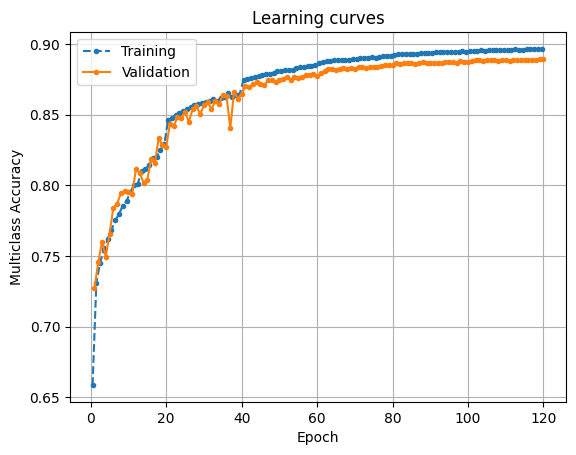

In [32]:
torch.manual_seed(42)
model2 = CoverTypeClassifier(NUM_INPUT_FEATURES, NUM_CLASSES, [200, 100, 50]).to(DEVICE)

full_history: TrainHistoryDict = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
for learning_rate in [0.16, 0.08, 0.04, 0.02, 0.01, 0.005]:
    n_epochs = 20
    optimizer = torch.optim.SGD(model2.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    history = train(
        model=model2,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric,
        train_loader=train_loader,
        valid_loader=valid_loader,
        n_epochs=n_epochs
    )

    full_history["train_losses"].extend(history["train_losses"])
    full_history["train_metrics"].extend(history["train_metrics"])
    full_history["valid_metrics"].extend(history["valid_metrics"])


draw_learning_curves(full_history, loss_fn_name="Multiclass Accuracy")


Tweaked attempt, letting it run for longer per epoch

Epoch 1/40, train loss (CrossEntropyLoss): 0.7975, train metric (MulticlassAccuracy): 0.6587, valid metric (MulticlassAccuracy): 0.7272
Epoch 2/40, train loss (CrossEntropyLoss): 0.6288, train metric (MulticlassAccuracy): 0.7309, valid metric (MulticlassAccuracy): 0.7454
Epoch 3/40, train loss (CrossEntropyLoss): 0.5920, train metric (MulticlassAccuracy): 0.7452, valid metric (MulticlassAccuracy): 0.7600
Epoch 4/40, train loss (CrossEntropyLoss): 0.5690, train metric (MulticlassAccuracy): 0.7548, valid metric (MulticlassAccuracy): 0.7495
Epoch 5/40, train loss (CrossEntropyLoss): 0.5530, train metric (MulticlassAccuracy): 0.7618, valid metric (MulticlassAccuracy): 0.7654
Epoch 6/40, train loss (CrossEntropyLoss): 0.5364, train metric (MulticlassAccuracy): 0.7684, valid metric (MulticlassAccuracy): 0.7841
Epoch 7/40, train loss (CrossEntropyLoss): 0.5224, train metric (MulticlassAccuracy): 0.7750, valid metric (MulticlassAccuracy): 0.7868
Epoch 8/40, train loss (CrossEntropyLoss): 0.510

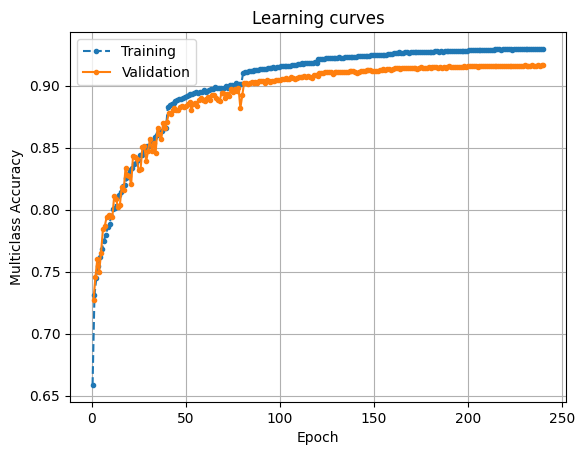

In [33]:
torch.manual_seed(42)
model3 = CoverTypeClassifier(NUM_INPUT_FEATURES, NUM_CLASSES, [200, 100, 50]).to(DEVICE)

full_history: TrainHistoryDict = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
for learning_rate in [0.16, 0.08, 0.04, 0.02, 0.01, 0.005]:
    n_epochs = 40
    optimizer = torch.optim.SGD(model3.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    history = train(
        model=model3,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric,
        train_loader=train_loader,
        valid_loader=valid_loader,
        n_epochs=n_epochs
    )

    full_history["train_losses"].extend(history["train_losses"])
    full_history["train_metrics"].extend(history["train_metrics"])
    full_history["valid_metrics"].extend(history["valid_metrics"])

draw_learning_curves(full_history, loss_fn_name="Multiclass Accuracy")


Epoch 1/15, train loss (CrossEntropyLoss): 0.7975, train metric (MulticlassAccuracy): 0.6587, valid metric (MulticlassAccuracy): 0.7272
Epoch 2/15, train loss (CrossEntropyLoss): 0.6288, train metric (MulticlassAccuracy): 0.7309, valid metric (MulticlassAccuracy): 0.7454
Epoch 3/15, train loss (CrossEntropyLoss): 0.5920, train metric (MulticlassAccuracy): 0.7452, valid metric (MulticlassAccuracy): 0.7600
Epoch 4/15, train loss (CrossEntropyLoss): 0.5690, train metric (MulticlassAccuracy): 0.7548, valid metric (MulticlassAccuracy): 0.7495
Epoch 5/15, train loss (CrossEntropyLoss): 0.5530, train metric (MulticlassAccuracy): 0.7618, valid metric (MulticlassAccuracy): 0.7654
Epoch 6/15, train loss (CrossEntropyLoss): 0.5364, train metric (MulticlassAccuracy): 0.7684, valid metric (MulticlassAccuracy): 0.7841
Epoch 7/15, train loss (CrossEntropyLoss): 0.5224, train metric (MulticlassAccuracy): 0.7750, valid metric (MulticlassAccuracy): 0.7868
Epoch 8/15, train loss (CrossEntropyLoss): 0.510

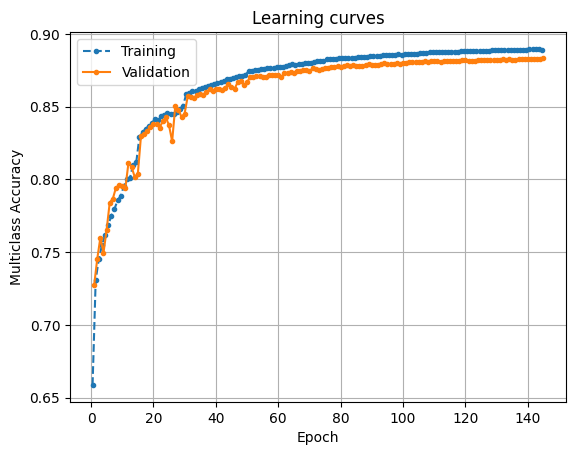

In [47]:
torch.manual_seed(42)
model4_nomomentumanddecay = CoverTypeClassifier(NUM_INPUT_FEATURES, NUM_CLASSES, [200, 100, 50]).to(DEVICE)

optimizer = torch.optim.SGD(
    model4_nomomentumanddecay.parameters(),
    lr=0.16,
    #momentum=0.9,
    #nesterov=True,
    #weight_decay=1e-4,
)
schedule = [(0.16, 15), (0.08, 15), (0.04, 20), (0.02, 25), (0.01, 30), (0.005, 40)]


full_history: TrainHistoryDict = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
for lr, n_epochs in schedule:

    for g in optimizer.param_groups:
        g["lr"] = lr

    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    history = train(
        model=model4_nomomentumanddecay,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric,
        train_loader=train_loader,
        valid_loader=valid_loader,
        n_epochs=n_epochs
    )

    full_history["train_losses"].extend(history["train_losses"])
    full_history["train_metrics"].extend(history["train_metrics"])
    full_history["valid_metrics"].extend(history["valid_metrics"])

draw_learning_curves(full_history, loss_fn_name="Multiclass Accuracy")


Epoch 1/15, train loss (CrossEntropyLoss): 0.6455, train metric (MulticlassAccuracy): 0.7258, valid metric (MulticlassAccuracy): 0.7655
Epoch 2/15, train loss (CrossEntropyLoss): 0.4943, train metric (MulticlassAccuracy): 0.7873, valid metric (MulticlassAccuracy): 0.7993
Epoch 3/15, train loss (CrossEntropyLoss): 0.4391, train metric (MulticlassAccuracy): 0.8137, valid metric (MulticlassAccuracy): 0.8253
Epoch 4/15, train loss (CrossEntropyLoss): 0.4045, train metric (MulticlassAccuracy): 0.8296, valid metric (MulticlassAccuracy): 0.8425
Epoch 5/15, train loss (CrossEntropyLoss): 0.3734, train metric (MulticlassAccuracy): 0.8446, valid metric (MulticlassAccuracy): 0.8539
Epoch 6/15, train loss (CrossEntropyLoss): 0.3526, train metric (MulticlassAccuracy): 0.8533, valid metric (MulticlassAccuracy): 0.8584
Epoch 7/15, train loss (CrossEntropyLoss): 0.3333, train metric (MulticlassAccuracy): 0.8622, valid metric (MulticlassAccuracy): 0.8667
Epoch 8/15, train loss (CrossEntropyLoss): 0.320

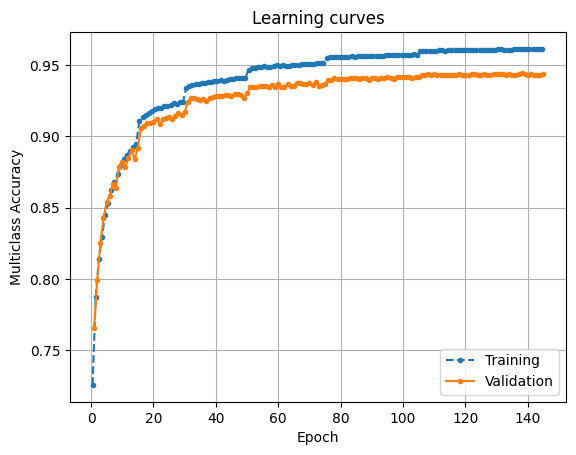

In [38]:
torch.manual_seed(42)
model4 = CoverTypeClassifier(NUM_INPUT_FEATURES, NUM_CLASSES, [200, 100, 50]).to(DEVICE)

optimizer = torch.optim.SGD(
    model4.parameters(),
    lr=0.16,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)
schedule = [(0.16, 15), (0.08, 15), (0.04, 20), (0.02, 25), (0.01, 30), (0.005, 40)]


full_history: TrainHistoryDict = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
for lr, n_epochs in schedule:

    for g in optimizer.param_groups:
        g["lr"] = lr

    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    history = train(
        model=model4,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric,
        train_loader=train_loader,
        valid_loader=valid_loader,
        n_epochs=n_epochs
    )

    full_history["train_losses"].extend(history["train_losses"])
    full_history["train_metrics"].extend(history["train_metrics"])
    full_history["valid_metrics"].extend(history["valid_metrics"])

draw_learning_curves(full_history, loss_fn_name="Multiclass Accuracy")


## Testing it

In [39]:
COVERTYPE_LABELS_0 = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz",
] # comes from the paper

### Manual Poking

Predict some using this model

In [44]:
model4.eval() # ! basically required to disable any kind of train-only behaviour like dropout

NUM_TEST = 30
X_new = X_test[:NUM_TEST].to(DEVICE)
with torch.no_grad():
    y_pred_logits: torch.Tensor = model4(X_new)

In [45]:
pred = y_pred_logits.argmax(dim=1)[:NUM_TEST].cpu()
true = y_test[:NUM_TEST].cpu()


pd.DataFrame({
    "true": np.take(COVERTYPE_LABELS_0, true),
    "pred": np.take(COVERTYPE_LABELS_0, pred),
    "match": np.where(true == pred, "✅", "❌"),
})


,true,pred,match
0,Spruce/Fir,Spruce/Fir,✅
1,Lodgepole Pine,Lodgepole Pine,✅
2,Lodgepole Pine,Lodgepole Pine,✅
3,Lodgepole Pine,Lodgepole Pine,✅
4,Lodgepole Pine,Lodgepole Pine,✅
5,Ponderosa Pine,Ponderosa Pine,✅
6,Lodgepole Pine,Lodgepole Pine,✅
7,Spruce/Fir,Spruce/Fir,✅
8,Lodgepole Pine,Lodgepole Pine,✅
9,Lodgepole Pine,Lodgepole Pine,✅


### Optimizing it with Optuna

#### OLD ATTEMPT (ignore)

In [ ]:
import optuna

def objective(trial: optuna.Trial) -> float:

    # ------------------------------------
    # the hyperparameters setup

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    momentum = trial.suggest_float("momentum", 0.0, 0.99)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    n_layers = trial.suggest_int("n_layers", 1, 5)

    layer_neurons: list[int] = []
    for layer_nr in range(n_layers):
        n_units = trial.suggest_categorical(f"n_units_l{layer_nr}", [32, 64, 128, 256, 512])
        layer_neurons.append(n_units)

    # ------------------------------------

    # init
    model = CoverTypeClassifier(
        n_inputs=NUM_INPUT_FEATURES,
        n_classes=NUM_CLASSES,
        layers_neurons=layer_neurons,
    ).to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=wd
    )
    loss_fn = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    history = train(
        model=model,
        optimizer=optimizer,
        criterion=loss_fn,
        metric=metric,
        train_loader=train_loader,
        valid_loader=valid_loader,
        n_epochs=10
    )

    # get the validation metric to optimise back & return it for optuna to use
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

Use it:

In [ ]:
torch.manual_seed(42)

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    direction="maximize", # this just means optuna will try to maximise the `validation_accuracy` we returned above
    sampler=sampler,
    storage="sqlite:///optuna.db", # <- to save and reuse study results easily
    load_if_exists=True, # <-           ^
    study_name="covertype_mlp_v4", # <- ^ (namespace the results to be able to reload them for *THIS* trial specifically, but reuse the local optuna.db file which is gitignored)
)

In [ ]:
study.optimize(objective, n_trials=10)

Results for best:

In [ ]:
study.best_params

In [ ]:
study.best_value # highest validation accuracy!

"Run it a few more times until satisfied"

In [ ]:
study.optimize(objective, n_trials=5)

In [ ]:
study.best_params

In [ ]:
study.best_value # highest validation accuracy!

#### New Attempt

In [49]:
import optuna

def objective(trial: optuna.Trial) -> float:
    torch.manual_seed(42)

    # ---- search space ----
    lr0 = trial.suggest_float("lr0", 1e-2, 3e-1, log=True)
    gamma = trial.suggest_float("gamma", 0.3, 0.8)  # multiply LR by this each stage
    step_epochs = trial.suggest_int("step_epochs", 5, 20) # epochs per stage
    n_stages = trial.suggest_int("n_stages", 3, 5)

    momentum = trial.suggest_float("momentum", 0.0, 0.95)
    wd = trial.suggest_float("weight_decay", 1e-6, 3e-4, log=True)

    n_layers = trial.suggest_int("n_layers", 2, 4)
    widths = []
    for i in range(n_layers):
        widths.append(trial.suggest_categorical(f"width_{i}", [64, 128, 256, 512]))

    # ---- build ----
    model = CoverTypeClassifier(NUM_INPUT_FEATURES, NUM_CLASSES, widths).to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr0,
        momentum=momentum,
        nesterov=(momentum > 0.0),
        weight_decay=wd,
    )
    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    best_val = 0.0
    lr = lr0

    # ---- staged training with pruning ----
    for stage in range(n_stages):
        for g in optimizer.param_groups:
            g["lr"] = lr

        history = train(
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            metric=metric,
            train_loader=train_loader,
            valid_loader=valid_loader,
            n_epochs=step_epochs,
        )

        val = max(history["valid_metrics"])
        best_val = max(best_val, val)

        trial.report(best_val, step=stage)
        if trial.should_prune():
            raise optuna.TrialPruned()

        lr *= gamma

    return best_val


Setup the trial (with DB) and then use it:

In [50]:
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner, # <- with pruner that cuts bad runs short
    study_name="covertype_quick_sweep",
    storage="sqlite:///optuna.db",
    load_if_exists=True,
)

[I 2026-01-19 02:53:38,456] A new study created in RDB with name: covertype_quick_sweep


In [51]:
study.optimize(objective, n_trials=20)

Epoch 1/16, train loss (CrossEntropyLoss): 1.0231, train metric (MulticlassAccuracy): 0.6057, valid metric (MulticlassAccuracy): 0.6743
Epoch 2/16, train loss (CrossEntropyLoss): 0.7578, train metric (MulticlassAccuracy): 0.6957, valid metric (MulticlassAccuracy): 0.7090
Epoch 3/16, train loss (CrossEntropyLoss): 0.7018, train metric (MulticlassAccuracy): 0.7150, valid metric (MulticlassAccuracy): 0.7184
Epoch 4/16, train loss (CrossEntropyLoss): 0.6756, train metric (MulticlassAccuracy): 0.7220, valid metric (MulticlassAccuracy): 0.7244
Epoch 5/16, train loss (CrossEntropyLoss): 0.6592, train metric (MulticlassAccuracy): 0.7276, valid metric (MulticlassAccuracy): 0.7286
Epoch 6/16, train loss (CrossEntropyLoss): 0.6470, train metric (MulticlassAccuracy): 0.7319, valid metric (MulticlassAccuracy): 0.7323
Epoch 7/16, train loss (CrossEntropyLoss): 0.6370, train metric (MulticlassAccuracy): 0.7351, valid metric (MulticlassAccuracy): 0.7354
Epoch 8/16, train loss (CrossEntropyLoss): 0.628

[I 2026-01-19 02:54:52,380] Trial 0 finished with value: 0.7877638936042786 and parameters: {'lr0': 0.03574712922600244, 'gamma': 0.7753571532049581, 'step_epochs': 16, 'n_stages': 4, 'momentum': 0.14821770842031468, 'weight_decay': 2.434542396201694e-06, 'n_layers': 2, 'width_0': 64, 'width_1': 64}. Best is trial 0 with value: 0.7877638936042786.


Epoch 16/16, train loss (CrossEntropyLoss): 0.5017, train metric (MulticlassAccuracy): 0.7881, valid metric (MulticlassAccuracy): 0.7878
Epoch 1/13, train loss (CrossEntropyLoss): 0.8680, train metric (MulticlassAccuracy): 0.6677, valid metric (MulticlassAccuracy): 0.7075
Epoch 2/13, train loss (CrossEntropyLoss): 0.6884, train metric (MulticlassAccuracy): 0.7198, valid metric (MulticlassAccuracy): 0.7248
Epoch 3/13, train loss (CrossEntropyLoss): 0.6580, train metric (MulticlassAccuracy): 0.7290, valid metric (MulticlassAccuracy): 0.7315
Epoch 4/13, train loss (CrossEntropyLoss): 0.6402, train metric (MulticlassAccuracy): 0.7339, valid metric (MulticlassAccuracy): 0.7349
Epoch 5/13, train loss (CrossEntropyLoss): 0.6264, train metric (MulticlassAccuracy): 0.7381, valid metric (MulticlassAccuracy): 0.7385
Epoch 6/13, train loss (CrossEntropyLoss): 0.6153, train metric (MulticlassAccuracy): 0.7418, valid metric (MulticlassAccuracy): 0.7399
Epoch 7/13, train loss (CrossEntropyLoss): 0.60

[I 2026-01-19 02:55:31,274] Trial 1 finished with value: 0.7807325124740601 and parameters: {'lr0': 0.018659959624904916, 'gamma': 0.45212112147976885, 'step_epochs': 13, 'n_stages': 4, 'momentum': 0.2766676831881398, 'weight_decay': 3.2781876533976136e-05, 'n_layers': 2, 'width_0': 512, 'width_1': 256}. Best is trial 0 with value: 0.7877638936042786.


Epoch 13/13, train loss (CrossEntropyLoss): 0.5186, train metric (MulticlassAccuracy): 0.7806, valid metric (MulticlassAccuracy): 0.7807
Epoch 1/6, train loss (CrossEntropyLoss): 0.6930, train metric (MulticlassAccuracy): 0.7245, valid metric (MulticlassAccuracy): 0.7668
Epoch 2/6, train loss (CrossEntropyLoss): 0.5152, train metric (MulticlassAccuracy): 0.7813, valid metric (MulticlassAccuracy): 0.7964
Epoch 3/6, train loss (CrossEntropyLoss): 0.4718, train metric (MulticlassAccuracy): 0.8009, valid metric (MulticlassAccuracy): 0.8146
Epoch 4/6, train loss (CrossEntropyLoss): 0.4440, train metric (MulticlassAccuracy): 0.8132, valid metric (MulticlassAccuracy): 0.8208
Epoch 5/6, train loss (CrossEntropyLoss): 0.4205, train metric (MulticlassAccuracy): 0.8249, valid metric (MulticlassAccuracy): 0.8335
Epoch 6/6, train loss (CrossEntropyLoss): 0.4067, train metric (MulticlassAccuracy): 0.8301, valid metric (MulticlassAccuracy): 0.8191
Epoch 1/6, train loss (CrossEntropyLoss): 0.3698, tra

...

Epoch 20/20, train loss (CrossEntropyLoss): 0.2356, train metric (MulticlassAccuracy): 0.9070, valid metric (MulticlassAccuracy): 0.8941
Epoch 1/18, train loss (CrossEntropyLoss): 0.8078, train metric (MulticlassAccuracy): 0.6757, valid metric (MulticlassAccuracy): 0.7397
Epoch 2/18, train loss (CrossEntropyLoss): 0.6042, train metric (MulticlassAccuracy): 0.7434, valid metric (MulticlassAccuracy): 0.7621
Epoch 3/18, train loss (CrossEntropyLoss): 0.5604, train metric (MulticlassAccuracy): 0.7609, valid metric (MulticlassAccuracy): 0.7682
Epoch 4/18, train loss (CrossEntropyLoss): 0.5328, train metric (MulticlassAccuracy): 0.7724, valid metric (MulticlassAccuracy): 0.7411
Epoch 5/18, train loss (CrossEntropyLoss): 0.5133, train metric (MulticlassAccuracy): 0.7812, valid metric (MulticlassAccuracy): 0.7809
Epoch 6/18, train loss (CrossEntropyLoss): 0.4906, train metric (MulticlassAccuracy): 0.7915, valid metric (MulticlassAccuracy): 0.7947
Epoch 7/18, train loss (CrossEntropyLoss): 0.47

[I 2026-01-19 03:06:04,306] Trial 18 finished with value: 0.8993115425109863 and parameters: {'lr0': 0.051668517235843696, 'gamma': 0.5084862639640247, 'step_epochs': 18, 'n_stages': 3, 'momentum': 0.594648857691116, 'weight_decay': 5.567869315749807e-06, 'n_layers': 4, 'width_0': 256, 'width_1': 256, 'width_2': 64, 'width_3': 256}. Best is trial 15 with value: 0.9245364665985107.


Epoch 18/18, train loss (CrossEntropyLoss): 0.2348, train metric (MulticlassAccuracy): 0.9080, valid metric (MulticlassAccuracy): 0.8989
Epoch 1/20, train loss (CrossEntropyLoss): 0.7623, train metric (MulticlassAccuracy): 0.6765, valid metric (MulticlassAccuracy): 0.7298
Epoch 2/20, train loss (CrossEntropyLoss): 0.6059, train metric (MulticlassAccuracy): 0.7390, valid metric (MulticlassAccuracy): 0.7571
Epoch 3/20, train loss (CrossEntropyLoss): 0.5679, train metric (MulticlassAccuracy): 0.7548, valid metric (MulticlassAccuracy): 0.7497
Epoch 4/20, train loss (CrossEntropyLoss): 0.5380, train metric (MulticlassAccuracy): 0.7675, valid metric (MulticlassAccuracy): 0.7716
Epoch 5/20, train loss (CrossEntropyLoss): 0.5162, train metric (MulticlassAccuracy): 0.7763, valid metric (MulticlassAccuracy): 0.7566
Epoch 6/20, train loss (CrossEntropyLoss): 0.4997, train metric (MulticlassAccuracy): 0.7842, valid metric (MulticlassAccuracy): 0.8024
Epoch 7/20, train loss (CrossEntropyLoss): 0.47

[I 2026-01-19 03:06:49,726] Trial 19 finished with value: 0.9058564305305481 and parameters: {'lr0': 0.14778822646699302, 'gamma': 0.7217138278764615, 'step_epochs': 20, 'n_stages': 3, 'momentum': 0.35661894404915717, 'weight_decay': 2.8685825998075128e-05, 'n_layers': 3, 'width_0': 256, 'width_1': 256, 'width_2': 64}. Best is trial 15 with value: 0.9245364665985107.


Epoch 20/20, train loss (CrossEntropyLoss): 0.2208, train metric (MulticlassAccuracy): 0.9122, valid metric (MulticlassAccuracy): 0.9059


In [52]:
study.best_value

0.9245364665985107

In [53]:
study.best_params

{'lr0': 0.154471425326819,
 'gamma': 0.5320832480224758,
 'step_epochs': 20,
 'n_stages': 3,
 'momentum': 0.6058465717616246,
 'weight_decay': 5.37902915217662e-05,
 'n_layers': 3,
 'width_0': 256,
 'width_1': 256,
 'width_2': 64}

In [55]:
eval_metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

In [54]:
model4.parameters

<bound method Module.parameters of CoverTypeClassifier(
  (mlp): Sequential(
    (0): CustomDense(in_features=54, out_features=200)
    (1): CustomDense(in_features=200, out_features=100)
    (2): CustomDense(in_features=100, out_features=50)
    (3): Linear(in_features=50, out_features=7, bias=True)
  )
)>

In [56]:
evaluate(model4, test_loader, eval_metric)

tensor(0.9435, device='cuda:0')